In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Matplotlib Version:", plt.matplotlib.__version__)
print("Seaborn Version:", sns.__version__)

Matplotlib Version: 3.11.1
Seaborn Version: 0.13.2


In [4]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-12,33.0,53.0,34.0,"6,566",436.0
1,2023-01-22,32.0,49.0,39.0,"7,122",227.0
2,2023-01-23,32.0,50.0,39.0,"7,280",181.0
3,2023-01-24,47.0,42.0,47.0,"7,433",175.0
4,2023-01-25,20.0,22.0,41.0,"7,538",180.0


In [5]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-12,33.0,53.0,34.0,"6,566",436.0
1,2023-01-22,32.0,49.0,39.0,"7,122",227.0
2,2023-01-23,32.0,50.0,39.0,"7,280",181.0
3,2023-01-24,47.0,42.0,47.0,"7,433",175.0
4,2023-01-25,20.0,22.0,41.0,"7,538",180.0


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/cleaned_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 1170
Columns: 6


In [7]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-12,33.0,53.0,34.0,"6,566",436.0
1,2023-01-22,32.0,49.0,39.0,"7,122",227.0
2,2023-01-23,32.0,50.0,39.0,"7,280",181.0
3,2023-01-24,47.0,42.0,47.0,"7,433",175.0
4,2023-01-25,20.0,22.0,41.0,"7,538",180.0


In [8]:
print(df.columns.tolist())

['Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care']


In [9]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Total System Load"],
    linewidth=2
)

plt.title("Total System Load Over Time")
plt.xlabel("Date")
plt.ylabel("Total System Load")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KeyError: 'Total System Load'

<Figure size 1400x600 with 0 Axes>

In [10]:
print(df.columns.tolist())

['Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care']


In [11]:
df["Total System Load"] = (
    df["Children in CBP custody"] +
    df["Children in HHS Care"]
)

print("Total System Load created successfully!")

TypeError: operation 'radd' not supported for dtype 'str' with dtype 'float64'

In [12]:
print(df["Children in CBP custody"].dtype)
print(df["Children in HHS Care"].dtype)

float64
str


In [13]:
df["Children in CBP custody"] = pd.to_numeric(
    df["Children in CBP custody"],
    errors="coerce"
)

df["Children in HHS Care"] = pd.to_numeric(
    df["Children in HHS Care"],
    errors="coerce"
)

In [14]:
print(df["Children in CBP custody"].dtype)
print(df["Children in HHS Care"].dtype)

float64
float64


In [15]:
df["Total System Load"] = (
    df["Children in CBP custody"] +
    df["Children in HHS Care"]
)

In [16]:
df[
    [
        "Date",
        "Children in CBP custody",
        "Children in HHS Care",
        "Total System Load"
    ]
].head()

,Date,Children in CBP custody,Children in HHS Care,Total System Load
0,2023-01-12,53.0,NaN,NaN
1,2023-01-22,49.0,NaN,NaN
2,2023-01-23,50.0,NaN,NaN
3,2023-01-24,42.0,NaN,NaN
4,2023-01-25,22.0,NaN,NaN


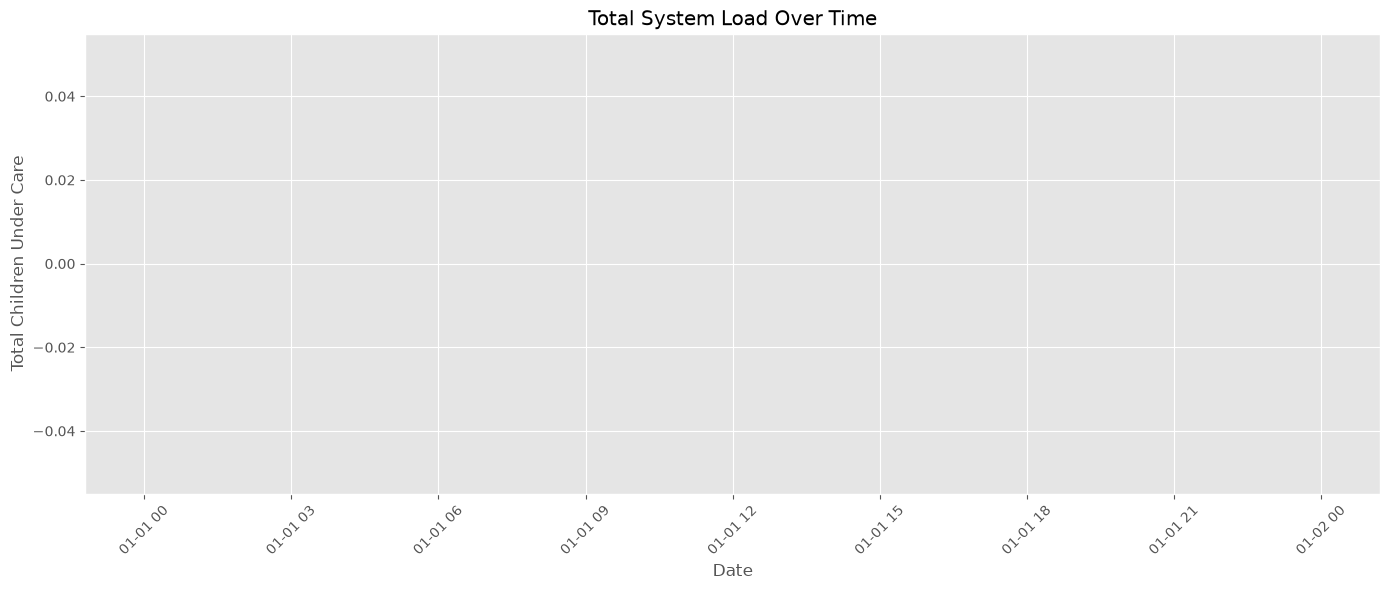

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Total System Load"], linewidth=2)

plt.title("Total System Load Over Time")
plt.xlabel("Date")
plt.ylabel("Total Children Under Care")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

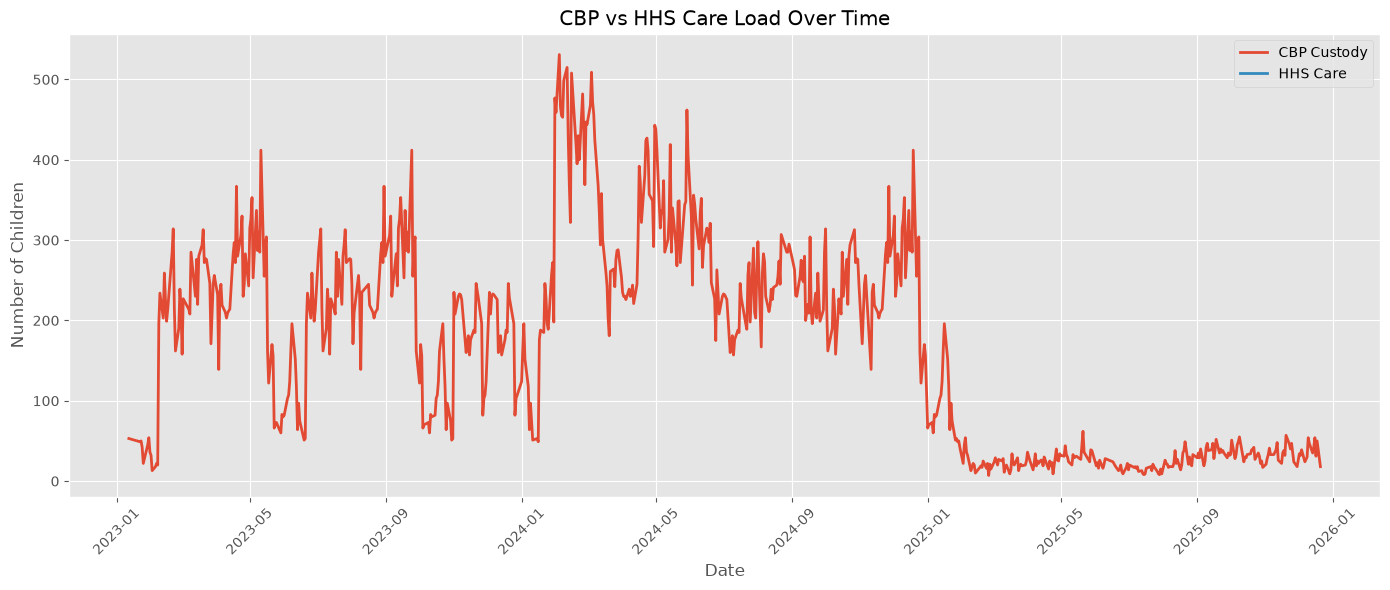

In [18]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Children in CBP custody"],
    label="CBP Custody",
    linewidth=2
)

plt.plot(
    df["Date"],
    df["Children in HHS Care"],
    label="HHS Care",
    linewidth=2
)

plt.title("CBP vs HHS Care Load Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Children")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
df["Net Daily Intake"] = (
    pd.to_numeric(
        df["Children transferred out of CBP custody"],
        errors="coerce"
    )
    -
    pd.to_numeric(
        df["Children discharged from HHS Care"],
        errors="coerce"
    )
)

In [20]:
df[["Date", "Net Daily Intake"]].head()

,Date,Net Daily Intake
0,2023-01-12,-402.0
1,2023-01-22,-188.0
2,2023-01-23,-142.0
3,2023-01-24,-128.0
4,2023-01-25,-139.0


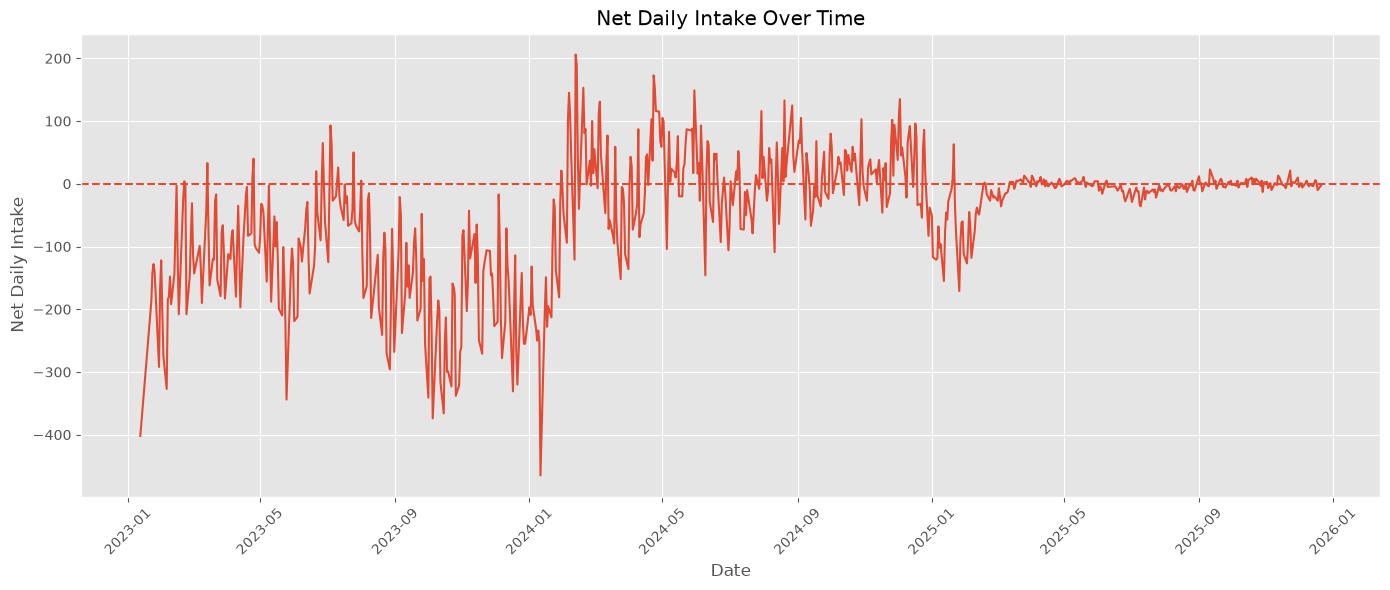

In [21]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Net Daily Intake"],
    linewidth=1.5
)

plt.axhline(0, linestyle="--")

plt.title("Net Daily Intake Over Time")
plt.xlabel("Date")
plt.ylabel("Net Daily Intake")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
df["7-Day Rolling Avg"] = (
    df["Total System Load"].rolling(7).mean()
)

df["14-Day Rolling Avg"] = (
    df["Total System Load"].rolling(14).mean()
)

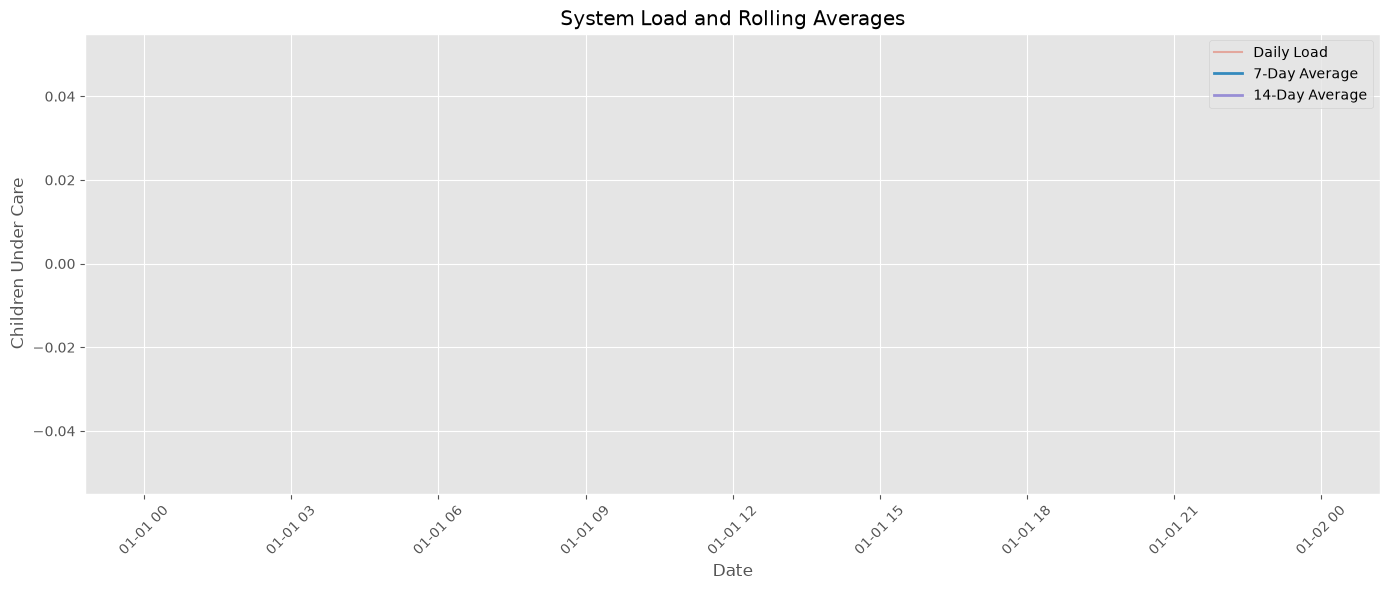

In [23]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Total System Load"],
    alpha=0.4,
    label="Daily Load"
)

plt.plot(
    df["Date"],
    df["7-Day Rolling Avg"],
    linewidth=2,
    label="7-Day Average"
)

plt.plot(
    df["Date"],
    df["14-Day Rolling Avg"],
    linewidth=2,
    label="14-Day Average"
)

plt.title("System Load and Rolling Averages")
plt.xlabel("Date")
plt.ylabel("Children Under Care")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
df["Month"] = df["Date"].dt.to_period("M")

monthly_load = (
    df.groupby("Month")["Total System Load"]
    .mean()
)

monthly_load

Month
2023-01   NaN
2023-02   NaN
2023-03   NaN
2023-04   NaN
2023-05   NaN
2023-06   NaN
2023-07   NaN
2023-08   NaN
2023-09   NaN
2023-10   NaN
2023-11   NaN
2023-12   NaN
2024-01   NaN
2024-02   NaN
2024-03   NaN
2024-04   NaN
2024-05   NaN
2024-06   NaN
2024-07   NaN
2024-08   NaN
2024-09   NaN
2024-10   NaN
2024-11   NaN
2024-12   NaN
2025-01   NaN
2025-02   NaN
2025-03   NaN
2025-04   NaN
2025-05   NaN
2025-06   NaN
2025-07   NaN
2025-08   NaN
2025-09   NaN
2025-10   NaN
2025-11   NaN
2025-12   NaN
Freq: M, Name: Total System Load, dtype: float64

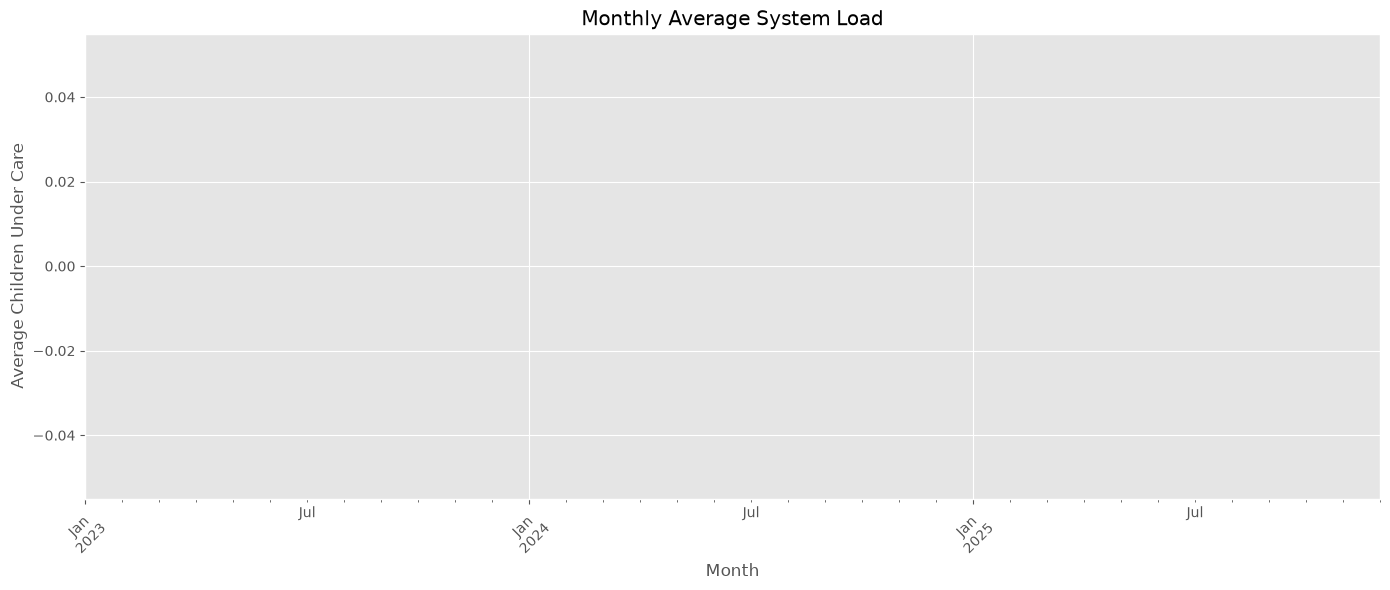

In [25]:
plt.figure(figsize=(14, 6))

monthly_load.plot(kind="line", marker="o")

plt.title("Monthly Average System Load")
plt.xlabel("Month")
plt.ylabel("Average Children Under Care")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
df["Backlog Indicator"] = df["Net Daily Intake"].cumsum()

In [27]:
df[["Date", "Net Daily Intake", "Backlog Indicator"]].head(10)

,Date,Net Daily Intake,Backlog Indicator
0,2023-01-12,-402.0,-402.0
1,2023-01-22,-188.0,-590.0
2,2023-01-23,-142.0,-732.0
3,2023-01-24,-128.0,-860.0
4,2023-01-25,-139.0,-999.0
5,2023-01-29,-292.0,-1291.0
6,2023-01-30,-167.0,-1458.0
7,2023-01-31,-122.0,-1580.0
8,2023-02-01,-204.0,-1784.0
9,2023-02-02,-275.0,-2059.0


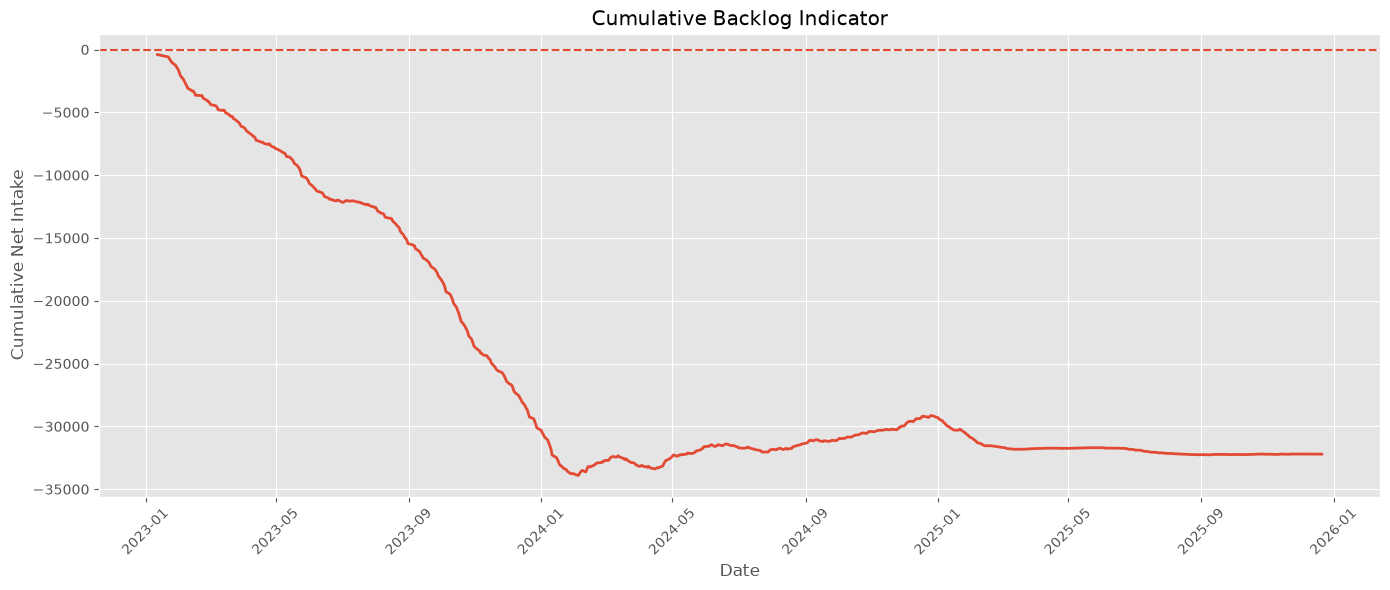

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Backlog Indicator"],
    linewidth=2
)

plt.axhline(0, linestyle="--")

plt.title("Cumulative Backlog Indicator")
plt.xlabel("Date")
plt.ylabel("Cumulative Net Intake")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
numeric_df = df.select_dtypes(include="number")

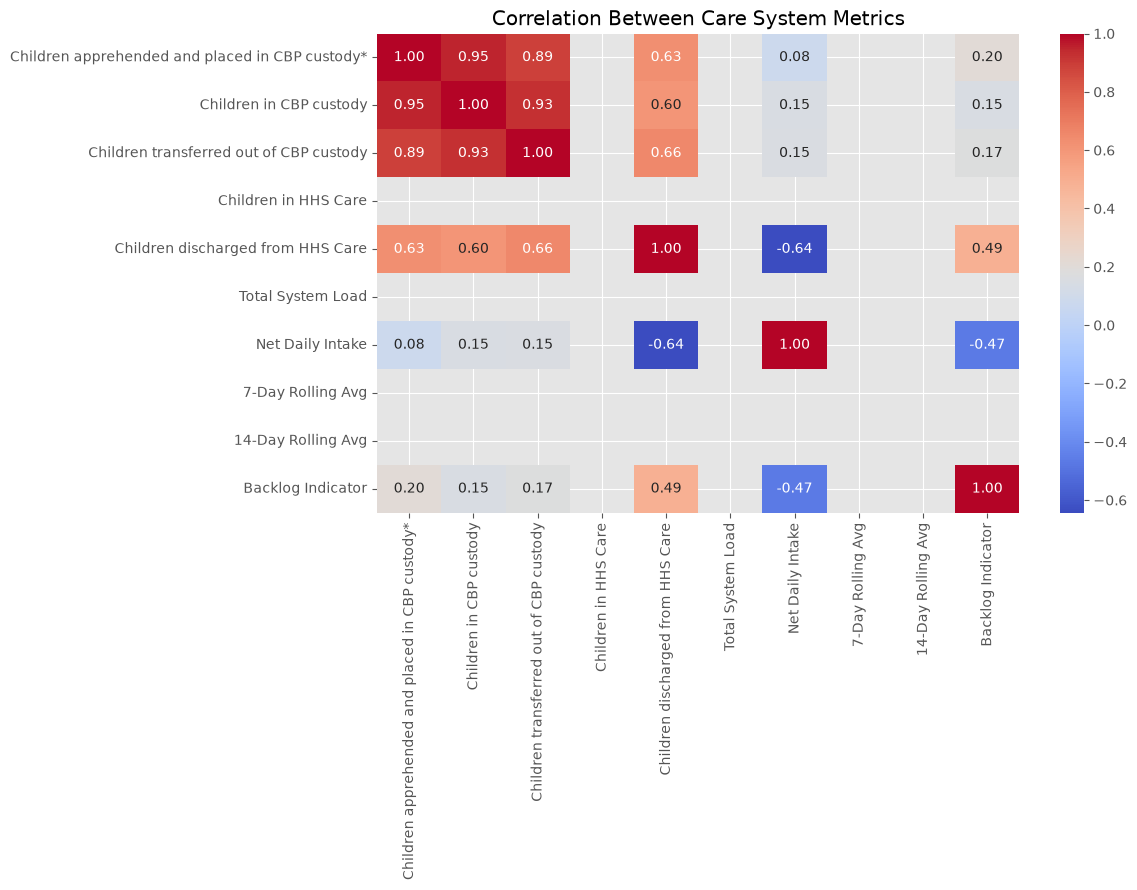

In [30]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Care System Metrics")
plt.tight_layout()
plt.show()

In [31]:
top_load_days = (
    df.nlargest(10, "Total System Load")
    [["Date", "Total System Load",
      "Children in CBP custody",
      "Children in HHS Care"]]
)

top_load_days

,Date,Total System Load,Children in CBP custody,Children in HHS Care
0,2023-01-12,NaN,53.0,NaN
1,2023-01-22,NaN,49.0,NaN
2,2023-01-23,NaN,50.0,NaN
3,2023-01-24,NaN,42.0,NaN
4,2023-01-25,NaN,22.0,NaN
5,2023-01-29,NaN,45.0,NaN
6,2023-01-30,NaN,54.0,NaN
7,2023-01-31,NaN,36.0,NaN
8,2023-02-01,NaN,32.0,NaN
9,2023-02-02,NaN,13.0,NaN


In [32]:
lowest_load_days = (
    df.nsmallest(10, "Total System Load")
    [["Date", "Total System Load",
      "Children in CBP custody",
      "Children in HHS Care"]]
)

lowest_load_days

,Date,Total System Load,Children in CBP custody,Children in HHS Care
0,2023-01-12,NaN,53.0,NaN
1,2023-01-22,NaN,49.0,NaN
2,2023-01-23,NaN,50.0,NaN
3,2023-01-24,NaN,42.0,NaN
4,2023-01-25,NaN,22.0,NaN
5,2023-01-29,NaN,45.0,NaN
6,2023-01-30,NaN,54.0,NaN
7,2023-01-31,NaN,36.0,NaN
8,2023-02-01,NaN,32.0,NaN
9,2023-02-02,NaN,13.0,NaN


In [33]:
print("===== EDA SUMMARY =====")
print("Total Records:", len(df))
print("Start Date:", df["Date"].min().date())
print("End Date:", df["Date"].max().date())
print("Average System Load:", round(df["Total System Load"].mean(), 2))
print("Maximum System Load:", df["Total System Load"].max())
print("Minimum System Load:", df["Total System Load"].min())
print("Average Net Daily Intake:", round(df["Net Daily Intake"].mean(), 2))

===== EDA SUMMARY =====
Total Records: 1170
Start Date: 2023-01-12
End Date: 2025-12-21
Average System Load: nan
Maximum System Load: nan
Minimum System Load: nan
Average Net Daily Intake: -44.74


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/analytics_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

print(df.head())

        Date  Children apprehended and placed in CBP custody*  \
0 2023-01-12                                             33.0   
1 2023-01-22                                             32.0   
2 2023-01-23                                             32.0   
3 2023-01-24                                             47.0   
4 2023-01-25                                             20.0   

   Children in CBP custody  Children transferred out of CBP custody  \
0                     53.0                                     34.0   
1                     49.0                                     39.0   
2                     50.0                                     39.0   
3                     42.0                                     47.0   
4                     22.0                                     41.0   

   Children in HHS Care  Children discharged from HHS Care  Total System Load  \
0                   NaN                              436.0                NaN   
1                   

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/analytics_data.csv"
)

df["Date"] = pd.to_datetime(df["Date"])

print(df[
    [
        "Date",
        "Children in CBP custody",
        "Children in HHS Care",
        "Children discharged from HHS Care",
        "Total System Load"
    ]
].head())

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/analytics_data.csv")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("First Date:", df["Date"].min())
print("Last Date:", df["Date"].max())

print(df[
    [
        "Date",
        "Children in CBP custody",
        "Children in HHS Care",
        "Children discharged from HHS Care",
        "Total System Load"
    ]
].head(10))

Rows: 720
Columns: 12
First Date: 2023-01-12 00:00:00
Last Date: 2025-12-21 00:00:00
        Date  Children in CBP custody  Children in HHS Care  \
0 2023-01-12                       53                  6566   
1 2023-01-22                       49                  7122   
2 2023-01-23                       50                  7280   
3 2023-01-24                       42                  7433   
4 2023-01-25                       22                  7538   
5 2023-01-29                       45                  7472   
6 2023-01-30                       54                  7743   
7 2023-01-31                       36                  7803   
8 2023-02-01                       32                  7903   
9 2023-02-02                       13                  7879   

   Children discharged from HHS Care  Total System Load  
0                                436               6619  
1                                227               7171  
2                                181           

In [2]:
print("HHS Care missing:",
      df["Children in HHS Care"].isna().sum())

print("HHS Discharged missing:",
      df["Children discharged from HHS Care"].isna().sum())

HHS Care missing: 0
HHS Discharged missing: 0


In [3]:
df[
    [
        "Children in CBP custody",
        "Children in HHS Care",
        "Children discharged from HHS Care",
        "Total System Load"
    ]
].describe()

,Children in CBP custody,Children in HHS Care,Children discharged from HHS Care,Total System Load
count,720.000000,720.000000,720.000000,720.000000
mean,171.494444,6061.275000,173.406944,6232.769444
std,126.354965,2833.070109,125.702841,2918.458078
min,7.000000,1972.000000,0.000000,2002.000000
25%,36.000000,2467.750000,19.750000,2500.750000
50%,193.000000,6406.500000,181.000000,6633.500000
75%,263.250000,8010.250000,267.000000,8249.500000
max,531.000000,11516.000000,505.000000,11762.000000


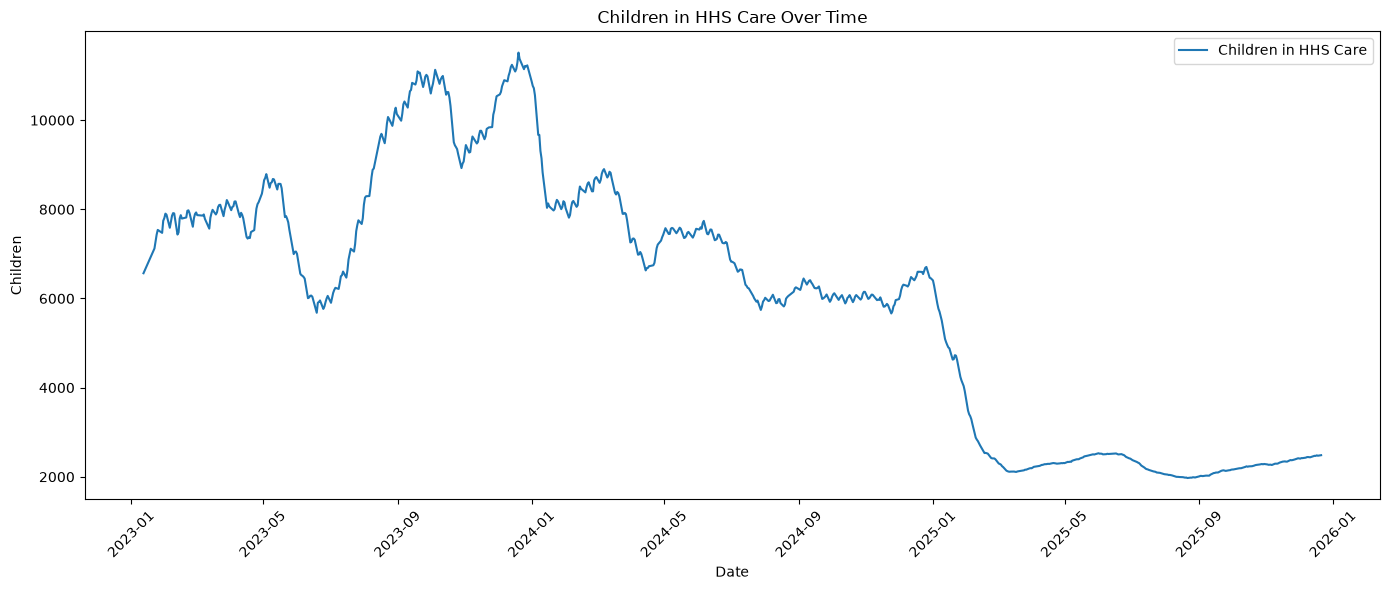

In [4]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Children in HHS Care"],
    label="Children in HHS Care"
)

plt.xlabel("Date")
plt.ylabel("Children")
plt.title("Children in HHS Care Over Time")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

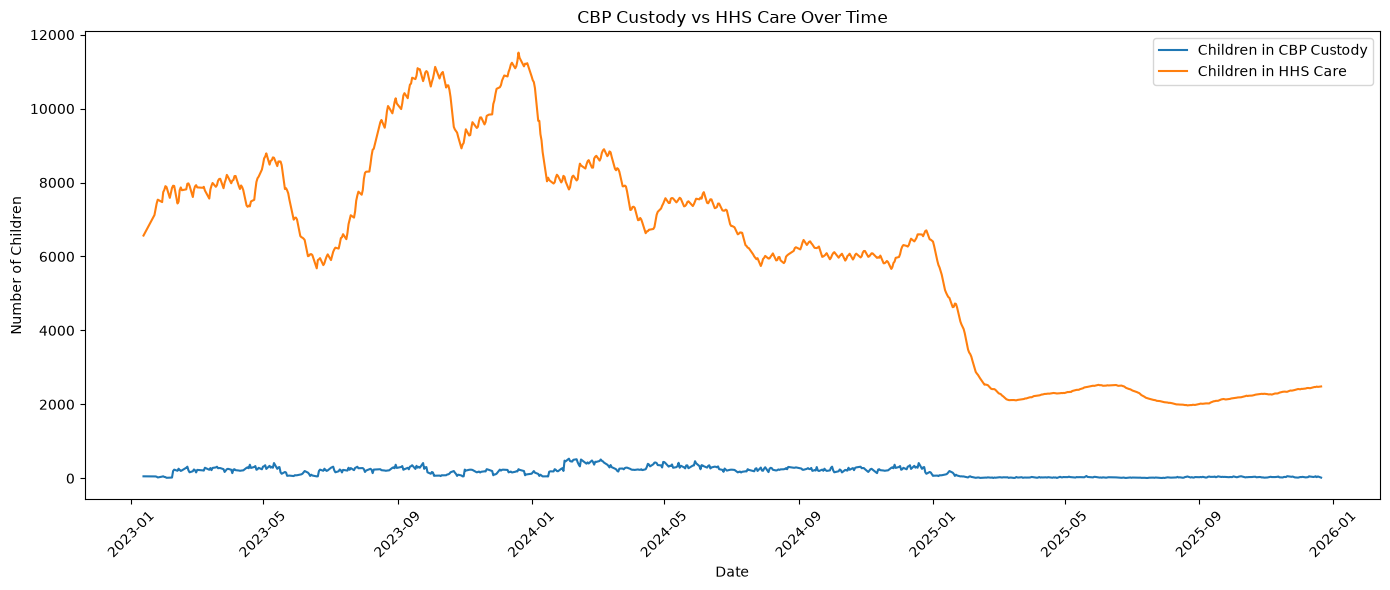

In [5]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Children in CBP custody"],
    label="Children in CBP Custody"
)

plt.plot(
    df["Date"],
    df["Children in HHS Care"],
    label="Children in HHS Care"
)

plt.xlabel("Date")
plt.ylabel("Number of Children")
plt.title("CBP Custody vs HHS Care Over Time")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
comparison = df[
    [
        "Children in CBP custody",
        "Children in HHS Care"
    ]
].describe()

print(comparison)

       Children in CBP custody  Children in HHS Care
count               720.000000            720.000000
mean                171.494444           6061.275000
std                 126.354965           2833.070109
min                   7.000000           1972.000000
25%                  36.000000           2467.750000
50%                 193.000000           6406.500000
75%                 263.250000           8010.250000
max                 531.000000          11516.000000


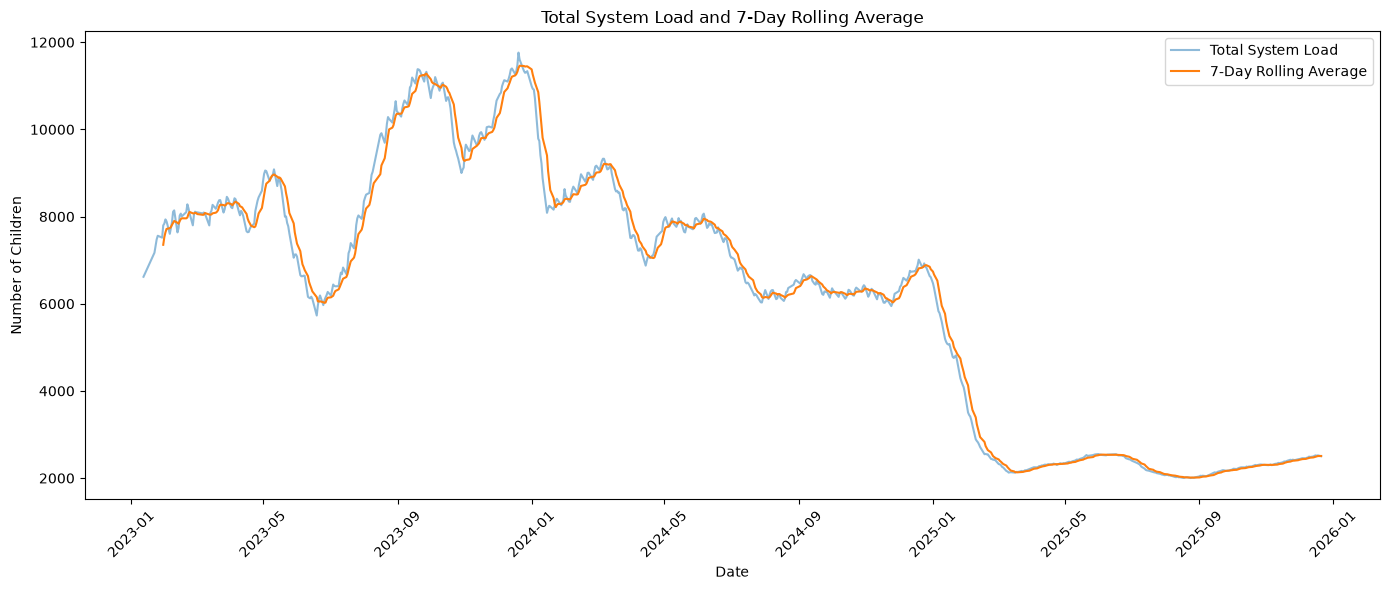

In [7]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Total System Load"],
    label="Total System Load",
    alpha=0.5
)

plt.plot(
    df["Date"],
    df["7-Day Rolling Load"],
    label="7-Day Rolling Average"
)

plt.xlabel("Date")
plt.ylabel("Number of Children")
plt.title("Total System Load and 7-Day Rolling Average")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
peak_load = df.loc[
    df["Total System Load"].idxmax()
]

print("Peak Total System Load:", peak_load["Total System Load"])
print("Peak Load Date:", peak_load["Date"])

print("\nTop 10 Peak Load Days:")

print(
    df[
        ["Date", "Total System Load"]
    ]
    .sort_values(
        "Total System Load",
        ascending=False
    )
    .head(10)
)

Peak Total System Load: 11762
Peak Load Date: 2023-12-20 00:00:00

Top 10 Peak Load Days:
          Date  Total System Load
224 2023-12-20              11762
225 2023-12-21              11603
223 2023-12-19              11476
220 2023-12-14              11399
161 2023-09-19              11382
162 2023-09-20              11374
219 2023-12-13              11373
163 2023-09-21              11352
226 2023-12-25              11340
222 2023-12-18              11337


In [9]:
lowest_load = df.loc[
    df["Total System Load"].idxmin()
]

print("Lowest Total System Load:", lowest_load["Total System Load"])
print("Lowest Load Date:", lowest_load["Date"])

print("\nBottom 10 Lowest Load Days:")

print(
    df[
        ["Date", "Total System Load"]
    ]
    .sort_values(
        "Total System Load",
        ascending=True
    )
    .head(10)
)

Lowest Total System Load: 2002
Lowest Load Date: 2025-08-24 00:00:00

Bottom 10 Lowest Load Days:
          Date  Total System Load
638 2025-08-24               2002
633 2025-08-17               2005
634 2025-08-18               2005
641 2025-08-27               2007
639 2025-08-25               2010
640 2025-08-26               2010
635 2025-08-19               2015
642 2025-08-28               2017
631 2025-08-13               2019
637 2025-08-21               2021


In [10]:
peak_load = df["Total System Load"].max()
lowest_load = df["Total System Load"].min()

load_difference = peak_load - lowest_load
load_reduction_percent = (load_difference / peak_load) * 100

print("Peak Load:", peak_load)
print("Lowest Load:", lowest_load)
print("Difference:", load_difference)
print("Reduction from Peak:", round(load_reduction_percent, 2), "%")

Peak Load: 11762
Lowest Load: 2002
Difference: 9760
Reduction from Peak: 82.98 %


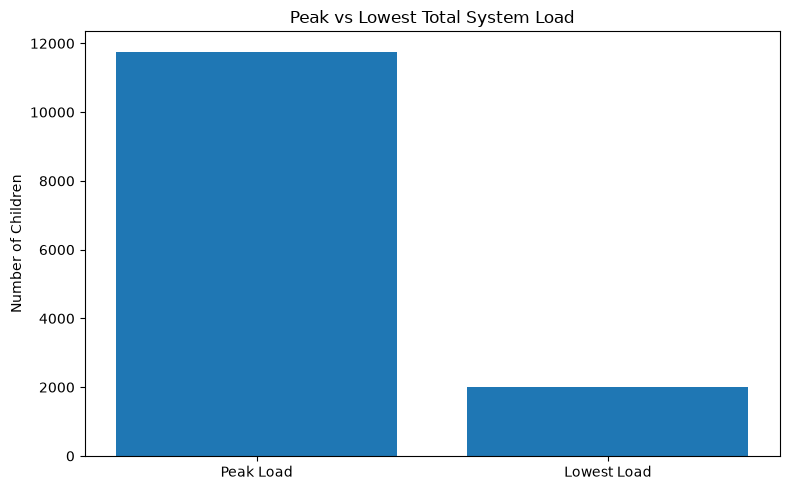

In [11]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["Peak Load", "Lowest Load"],
    [peak_load, lowest_load]
)

plt.ylabel("Number of Children")
plt.title("Peak vs Lowest Total System Load")

plt.tight_layout()
plt.show()

In [12]:
monthly_load = (
    df.set_index("Date")
      .resample("MS")["Total System Load"]
      .mean()
      .reset_index()
)

print(monthly_load.head())
print("\nTotal Months:", len(monthly_load))

        Date  Total System Load
0 2023-01-01        7413.500000
1 2023-02-01        7967.105263
2 2023-03-01        8190.473684
3 2023-04-01        8092.857143
4 2023-05-01        8404.090909

Total Months: 36


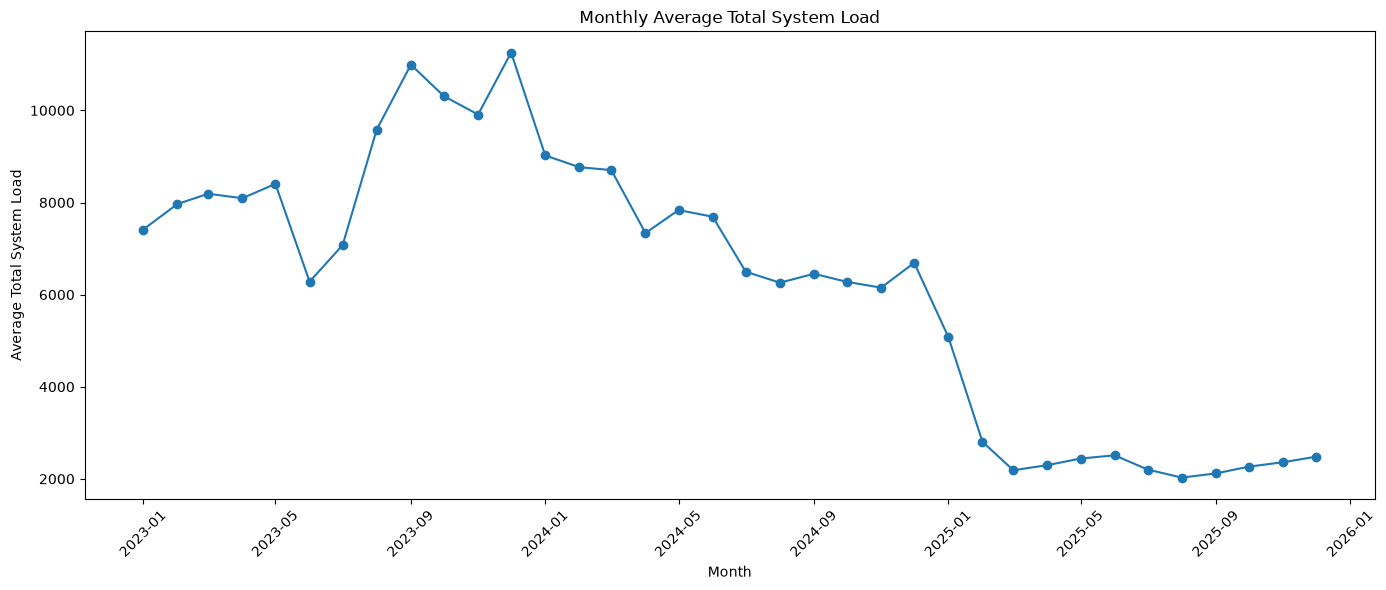

In [13]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_load["Date"],
    monthly_load["Total System Load"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Total System Load")
plt.title("Monthly Average Total System Load")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
monthly_compare = (
    df.set_index("Date")
      .resample("MS")[
          [
              "Children in HHS Care",
              "Children in CBP custody"
          ]
      ]
      .mean()
      .reset_index()
)

print(monthly_compare.head())
print("\nTotal Months:", len(monthly_compare))

        Date  Children in HHS Care  Children in CBP custody
0 2023-01-01           7369.625000                43.875000
1 2023-02-01           7795.789474               171.315789
2 2023-03-01           7945.368421               245.105263
3 2023-04-01           7842.666667               250.190476
4 2023-05-01           8187.136364               216.954545

Total Months: 36


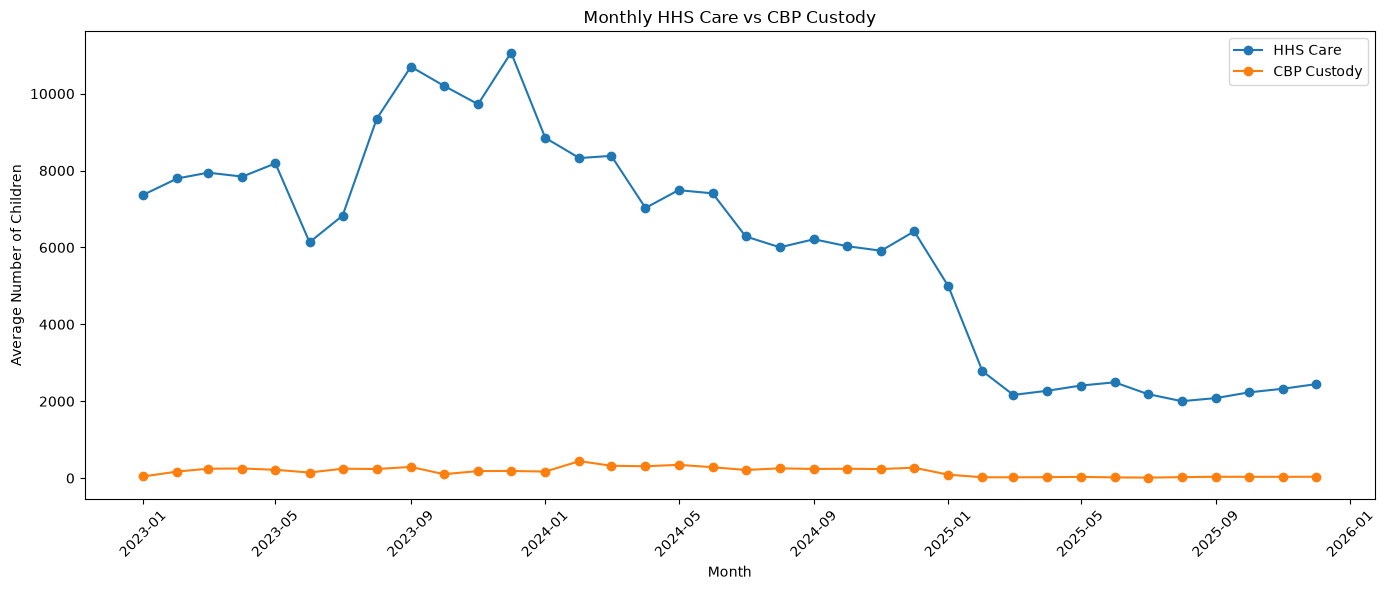

In [15]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_compare["Date"],
    monthly_compare["Children in HHS Care"],
    marker="o",
    label="HHS Care"
)

plt.plot(
    monthly_compare["Date"],
    monthly_compare["Children in CBP custody"],
    marker="o",
    label="CBP Custody"
)

plt.xlabel("Month")
plt.ylabel("Average Number of Children")
plt.title("Monthly HHS Care vs CBP Custody")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
monthly_discharge = (
    df.set_index("Date")
      .resample("MS")["Children discharged from HHS Care"]
      .mean()
      .reset_index()
)

print(monthly_discharge.head())

print("\nHighest Monthly Average Discharge:")

print(
    monthly_discharge.loc[
        monthly_discharge["Children discharged from HHS Care"].idxmax()
    ]
)

        Date  Children discharged from HHS Care
0 2023-01-01                         232.000000
1 2023-02-01                         272.789474
2 2023-03-01                         282.894737
3 2023-04-01                         269.904762
4 2023-05-01                         284.363636

Highest Monthly Average Discharge:
Date                                 2023-12-01 00:00:00
Children discharged from HHS Care             358.105263
Name: 11, dtype: object


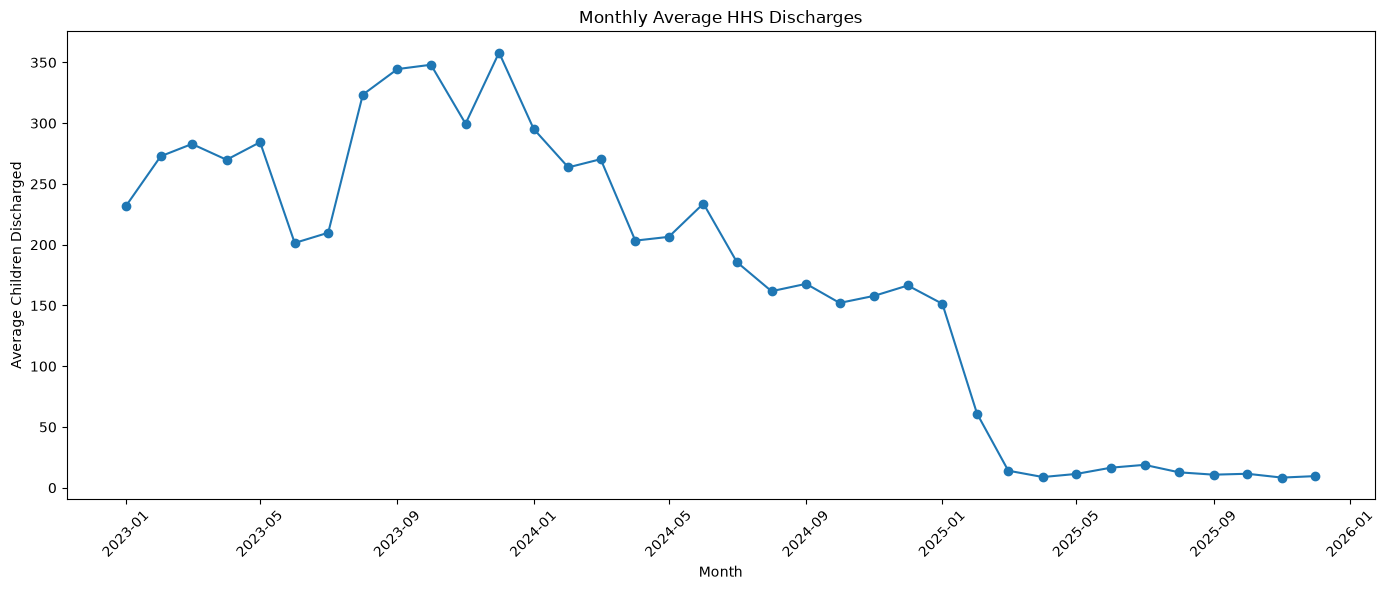

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_discharge["Date"],
    monthly_discharge["Children discharged from HHS Care"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Children Discharged")
plt.title("Monthly Average HHS Discharges")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
net_intake_stats = df["Net Daily Intake"].describe()

print(net_intake_stats)

count    720.000000
mean     -44.738889
std       95.863856
min     -465.000000
25%      -94.250000
50%      -11.500000
75%        5.250000
max      206.000000
Name: Net Daily Intake, dtype: float64


In [19]:
positive_days = (df["Net Daily Intake"] > 0).sum()
negative_days = (df["Net Daily Intake"] < 0).sum()
zero_days = (df["Net Daily Intake"] == 0).sum()

print("Positive Net Intake Days:", positive_days)
print("Negative Net Intake Days:", negative_days)
print("Zero Net Intake Days:", zero_days)

Positive Net Intake Days: 238
Negative Net Intake Days: 475
Zero Net Intake Days: 7


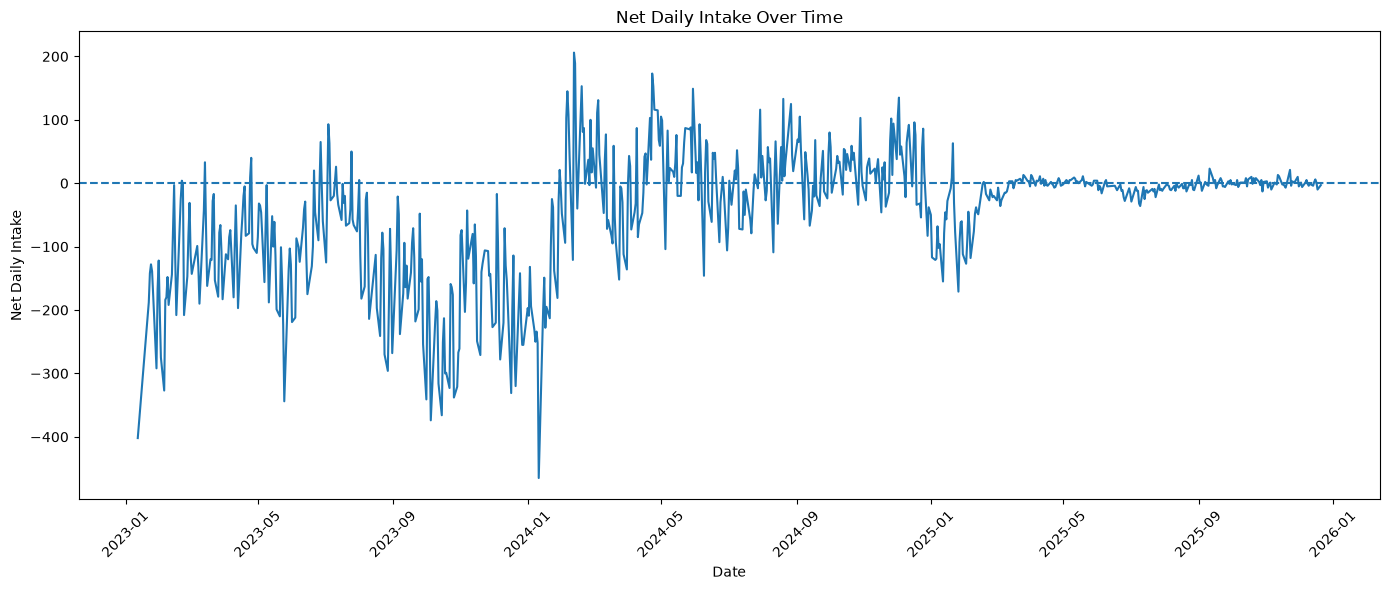

In [20]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Net Daily Intake"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Net Daily Intake")
plt.title("Net Daily Intake Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
backlog_days = df[df["Net Daily Intake"] > 0].copy()

print("Total Backlog/Pressure Days:", len(backlog_days))

print("\nHighest Pressure Days:")

print(
    backlog_days[
        ["Date", "Net Daily Intake", "Total System Load"]
    ]
    .sort_values(
        "Net Daily Intake",
        ascending=False
    )
    .head(10)
)

Total Backlog/Pressure Days: 238

Highest Pressure Days:
          Date  Net Daily Intake  Total System Load
259 2024-02-12               206               8522
260 2024-02-13               189               8717
309 2024-04-23               173               7394
263 2024-02-19               153               8800
310 2024-04-24               153               7539
335 2024-05-30               149               7969
255 2024-02-06               145               8500
461 2024-12-03               135               6422
391 2024-08-20               133               6269
274 2024-03-05               131               9272


In [22]:
monthly_pressure = (
    df.set_index("Date")
      .resample("MS")["Net Daily Intake"]
      .mean()
      .reset_index()
)

print(monthly_pressure.head())

        Date  Net Daily Intake
0 2023-01-01       -197.500000
1 2023-02-01       -134.000000
2 2023-03-01       -104.000000
3 2023-04-01        -81.000000
4 2023-05-01       -119.727273


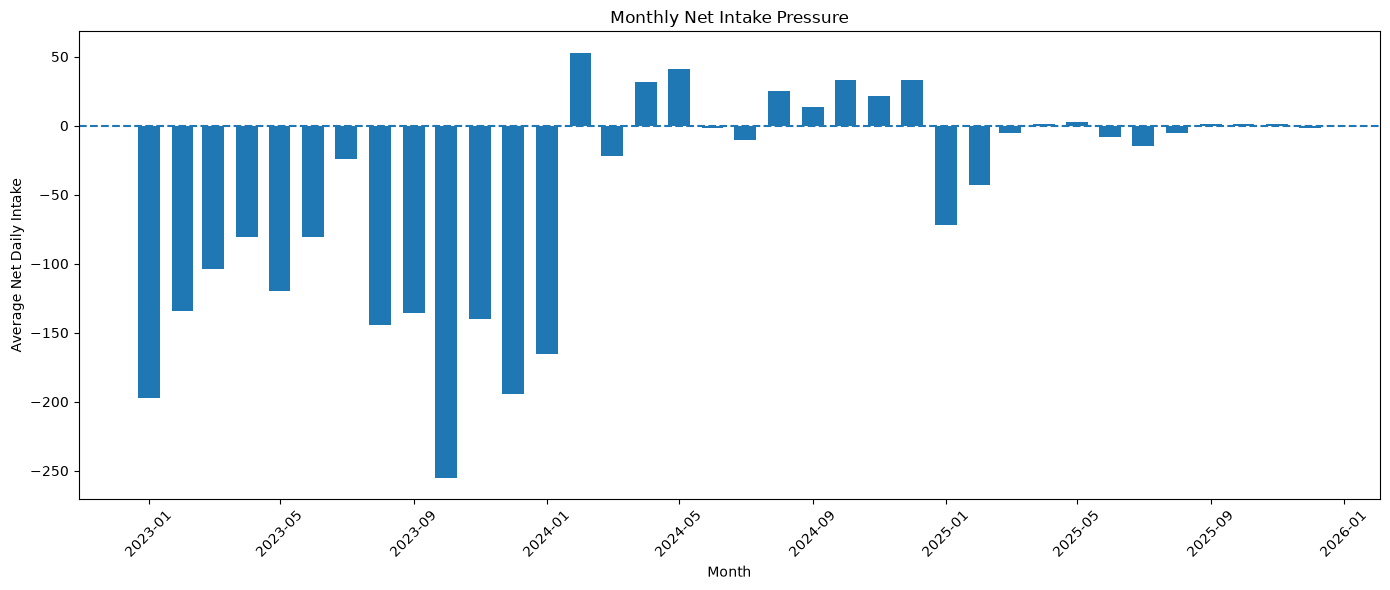

In [23]:
plt.figure(figsize=(14, 6))

plt.bar(
    monthly_pressure["Date"],
    monthly_pressure["Net Daily Intake"],
    width=20
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Month")
plt.ylabel("Average Net Daily Intake")
plt.title("Monthly Net Intake Pressure")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
corr_cols = [
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care",
    "Total System Load",
    "Net Daily Intake"
]

correlation = df[corr_cols].corr()

print(correlation.round(2))

                                                 Children apprehended and placed in CBP custody*  \
Children apprehended and placed in CBP custody*                                             1.00   
Children in CBP custody                                                                     0.95   
Children transferred out of CBP custody                                                     0.89   
Children in HHS Care                                                                        0.69   
Children discharged from HHS Care                                                           0.63   
Total System Load                                                                           0.71   
Net Daily Intake                                                                            0.08   

                                                 Children in CBP custody  \
Children apprehended and placed in CBP custody*                     0.95   
Children in CBP custody                        

In [25]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix - System Capacity Metrics")
plt.tight_layout()
plt.show()

NameError: name 'sns' is not defined

<Figure size 1000x700 with 0 Axes>

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Seaborn Version:", sns.__version__)

Seaborn Version: 0.13.2


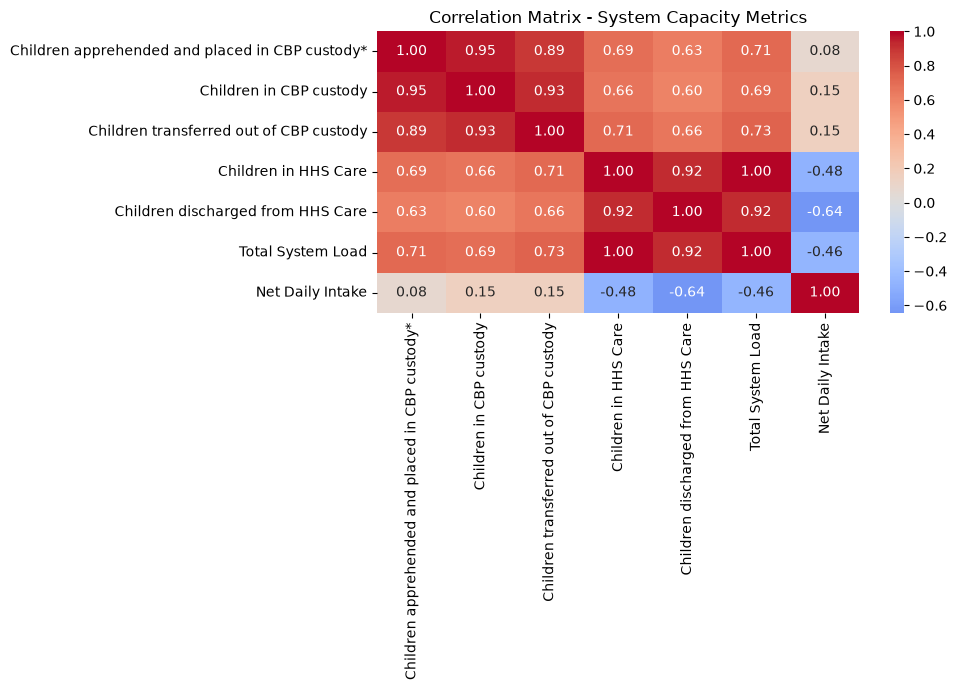

In [27]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix - System Capacity Metrics")
plt.tight_layout()
plt.show()

In [28]:
# Correlation with Total System Load

load_corr = (
    correlation["Total System Load"]
    .drop("Total System Load")
    .sort_values(ascending=False)
)

print("Correlation with Total System Load:")
print(load_corr.round(2))

Correlation with Total System Load:
Children in HHS Care                               1.00
Children discharged from HHS Care                  0.92
Children transferred out of CBP custody            0.73
Children apprehended and placed in CBP custody*    0.71
Children in CBP custody                            0.69
Net Daily Intake                                  -0.46
Name: Total System Load, dtype: float64


In [29]:
# Correlation with Net Daily Intake

intake_corr = (
    correlation["Net Daily Intake"]
    .drop("Net Daily Intake")
    .sort_values(ascending=False)
)

print("\nCorrelation with Net Daily Intake:")
print(intake_corr.round(2))


Correlation with Net Daily Intake:
Children transferred out of CBP custody            0.15
Children in CBP custody                            0.15
Children apprehended and placed in CBP custody*    0.08
Total System Load                                 -0.46
Children in HHS Care                              -0.48
Children discharged from HHS Care                 -0.64
Name: Net Daily Intake, dtype: float64


In [30]:
print("===== EDA SUMMARY =====")

print("\nDataset:")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("First Date:", df["Date"].min())
print("Last Date:", df["Date"].max())

print("\nSystem Load:")
print("Peak Total System Load:", df["Total System Load"].max())
print("Lowest Total System Load:", df["Total System Load"].min())

print("\nNet Daily Intake:")
print("Average:", round(df["Net Daily Intake"].mean(), 2))
print("Positive Days:", (df["Net Daily Intake"] > 0).sum())
print("Negative Days:", (df["Net Daily Intake"] < 0).sum())

print("\nStrongest Correlation with Total System Load:")
print(load_corr.head(3))

print("\nStrongest Negative Correlation with Net Daily Intake:")
print(intake_corr.sort_values().head(3))

===== EDA SUMMARY =====

Dataset:
Rows: 720
Columns: 12
First Date: 2023-01-12 00:00:00
Last Date: 2025-12-21 00:00:00

System Load:
Peak Total System Load: 11762
Lowest Total System Load: 2002

Net Daily Intake:
Average: -44.74
Positive Days: 238
Negative Days: 475

Strongest Correlation with Total System Load:
Children in HHS Care                       0.999475
Children discharged from HHS Care          0.920008
Children transferred out of CBP custody    0.733061
Name: Total System Load, dtype: float64

Strongest Negative Correlation with Net Daily Intake:
Children discharged from HHS Care   -0.643944
Children in HHS Care                -0.482760
Total System Load                   -0.462161
Name: Net Daily Intake, dtype: float64
